In [2]:
# ==============================
# 🚀 1️⃣ Install & Verify CUDA 
# ==============================

import tensorflow as tf

def check_cuda():
    """Check if CUDA is available and display GPU info."""
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✅ CUDA is available! {len(gpus)} GPU(s) detected.")
        for gpu in gpus:
            print(f" - {gpu}")
    else:
        print("❌ No GPU found. Running on CPU.")

check_cuda()


✅ CUDA is available! 1 GPU(s) detected.
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# ==============================
# 📂 2️⃣ Load & Process Data 
# ==============================

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

def load_data(file_path):
    """
    Load the CSV file containing embeddings and labels.
    - The file should have 3 columns: URL (ignored), Embedding (string), Label ("1,0" for normal, "0,1" for abnormal).
    """
    df = pd.read_csv(file_path)

    # Convert embeddings from strings to NumPy arrays
    df["embedding"] = df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=","))

    # Convert labels: "1,0" -> 1 (Normal), "0,1" -> 0 (Abnormal)
    df["label"] = df["label"].apply(lambda x: 1 if x == "1,0" else 0)

    # Convert to NumPy arrays
    embeddings = np.stack(df["embedding"].values)
    labels = np.array(df["label"].values)

    # Split into train/test (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.96, random_state=42)

    # Create TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64).shuffle(1000).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

    print(f"✅ Data loaded: {len(X_train)} training samples, {len(X_test)} testing samples")

    for x, y in train_ds.take(1):
        print(f"Batch shapes: X={x.shape}, y={y.shape}")
        
    return train_ds, test_ds, X_train.shape[1]

# Call this function with your dataset
train_ds, test_ds, input_dim = load_data(r"~/final_merged_data.csv")


✅ Data loaded: 273 training samples, 6557 testing samples
Batch shapes: X=(64, 1408), y=(64,)


2025-02-15 16:36:57.395693: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
# ==============================
# 🏗️ 3️⃣ Build Optimized Model
# ==============================

from tensorflow.keras import layers, Model

def create_model(input_dim):
    """Create a neural network optimized for binary classification using embeddings."""
    inputs = tf.keras.Input(shape=(input_dim,))
    
    # First Dense Layer with Residual Connection
    x = layers.Dense(512, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # Second Dense Layer
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Third Dense Layer
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # Third Dense Layer (Residual)
    x_residual = layers.Dense(128, activation="relu")(x)
    x = layers.Add()([x, x_residual])  # Residual connection
    x = layers.BatchNormalization()(x)
    
    # Output Layer (Binary Classification)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    # Compile Model
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    print("✅ Model created successfully")
    return model

# Build the model
model = create_model(input_dim)
model.summary()


✅ Model created successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1408)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    721,408 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        129 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 906,369 (3.46 MB)

 Trainable params: 904,321 (3.45 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [29]:
# ==============================
# 🚀 4️⃣ Train the Model 
# ==============================

def train_model(model, train_ds, test_ds, epochs=35):
    """Train the neural network on the dataset."""
    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=epochs,
        verbose=1
    )
    print("✅ Training completed!")
    return history

# Train the model
history = train_model(model, train_ds, test_ds)

Epoch 1/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6993 - auc: 0.7682 - loss: 0.6061 - val_accuracy: 0.7284 - val_auc: 0.8272 - val_loss: 0.5304
Epoch 2/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7523 - auc: 0.8356 - loss: 0.4959 - val_accuracy: 0.7343 - val_auc: 0.8285 - val_loss: 0.5214
Epoch 3/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7594 - auc: 0.8453 - loss: 0.4811 - val_accuracy: 0.7570 - val_auc: 0.8334 - val_loss: 0.5113
Epoch 4/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7671 - auc: 0.8511 - loss: 0.4727 - val_accuracy: 0.7474 - val_auc: 0.8299 - val_loss: 0.5064
Epoch 5/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7787 - auc: 0.8531 - loss: 0.4660 - val_accuracy: 0.7555 - val_auc: 0.8329 - val_loss: 0.5065
Epoch 6/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7714 - auc: 0.8472 - loss: 0.4742 - val_accuracy: 0.7562 - val_auc: 0.8359 - val_loss: 0.5205
Epoch 7/35
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step -

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import keras_tuner as kt  # or "import kerastuner as kt" if you use an older version

# Ensure input_dim is defined from your data-loading code:
# e.g., train_ds, test_ds, input_dim = load_data("your_embeddings.csv")

def build_model(hp):
    """
    Build a model with a residual connection where several hyperparameters are tunable.
    This mirrors your original architecture:
      - A first Dense layer (with BatchNorm and Dropout)
      - A second Dense layer (with BatchNorm and Dropout)
      - A residual branch from the second layer
      - An output layer for binary classification.
    """
    inputs = tf.keras.Input(shape=(input_dim,))
    
    # First Dense Layer with tunable parameters
    units1 = hp.Int('units1', min_value=256, max_value=512, step=64, default=512)
    activation = hp.Choice('activation', values=['relu', 'swish'], default='relu')
    dropout1 = hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    x = layers.Dense(units1, activation=activation)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout1)(x)
    
    # Second Dense Layer with tunable parameters
    units2 = hp.Int('units2', min_value=128, max_value=256, step=64, default=256)
    dropout2 = hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    x = layers.Dense(units2, activation=activation)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout2)(x)


    units2 = hp.Int('units2', min_value=128, max_value=256, step=64, default=256)
    dropout2 = hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    x = layers.Dense(units2, activation=activation)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout2)(x)
    
    # Residual branch: Project the output of the second Dense layer through another Dense layer.
    x_residual = layers.Dense(units2, activation=activation)(x)
    x = layers.Add()([x, x_residual])
    x = layers.BatchNormalization()(x)
    
    # Output Layer for binary classification
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    
    # Tune the learning rate for the Adam optimizer.
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4], default=1e-3)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.BinaryAccuracy(name='accuracy')]
    )
    
    return model

# Set up the tuner using RandomSearch
tuner = kt.RandomSearch(
    build_model,
    objective='val_auc',         # We aim to maximize the validation AUC
    max_trials=10,               # You can increase this number to search a wider space
    executions_per_trial=1,      # Number of models to build per trial (set higher for more robustness)
    directory='kt_dir',
    project_name='ct_classification',
    overwrite=True
)

# Display the search space summary
tuner.search_space_summary()

# Run the hyperparameter search.
# Make sure that train_ds and test_ds are your tf.data.Dataset objects.
tuner.search(train_ds, validation_data=test_ds, epochs=35, verbose=1)

# Print a summary of the search results
tuner.results_summary()

# Retrieve the best model and display its summary.
best_model = tuner.get_best_models(num_models=1)[0]
print("Best model summary:")
best_model.summary()

# Optionally, evaluate the best model on the test dataset.
test_loss, test_accuracy, test_auc = best_model.evaluate(test_ds)
print(f"Test AUC: {test_auc:.3f}")


Trial 10 Complete [00h 00m 20s]
val_auc: 0.8344535827636719

Best val_auc So Far: 0.8382965922355652
Total elapsed time: 00h 03m 19s
Results summary
Results in kt_dir/ct_classification
Showing 10 best trials
Objective(name="val_auc", direction="max")

Trial 06 summary
Hyperparameters:
units1: 512
activation: relu
dropout1: 0.2
units2: 256
dropout2: 0.30000000000000004
learning_rate: 0.0001
Score: 0.8382965922355652

Trial 05 summary
Hyperparameters:
units1: 320
activation: swish
dropout1: 0.30000000000000004
units2: 192
dropout2: 0.4
learning_rate: 0.0001
Score: 0.8381357789039612

Trial 03 summary
Hyperparameters:
units1: 448
activation: relu
dropout1: 0.4
units2: 192
dropout2: 0.4
learning_rate: 0.0001
Score: 0.8379054069519043

Trial 02 summary
Hyperparameters:
units1: 320
activation: swish
dropout1: 0.2
units2: 128
dropout2: 0.2
learning_rate: 0.0001
Score: 0.8376855850219727

Trial 04 summary
Hyperparameters:
units1: 512
activation: swish
dropout1: 0.30000000000000004
units2: 256


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1408)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    721,408 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 922,881 (3.52 MB)

 Trainable params: 920,833 (3.51 MB)

 Non-trainable params: 2,048 (8.00 KB)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7721 - auc: 0.8514 - loss: 0.4775  
Test AUC: 0.755


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

def build_model(hp):
    """Build a tunable neural network model with a decreasing neuron structure."""
    inputs = keras.Input(shape=(input_dim,))
    
    # Define first layer (largest neuron count)
    units1 = hp.Choice("units_1", [512, 1024])  # Start with a high neuron count
    x = layers.Dense(units1, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(hp.Float("dropout_1", 0.2, 0.4, step=0.1))(x)
    
    # Define second layer (smaller than first)
    units2 = hp.Choice("units_2", [256, 512])  # Should be smaller than units1
    x = layers.Dense(units2, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(hp.Float("dropout_2", 0.2, 0.4, step=0.1))(x)
    
    # Define third layer (smallest)
    units3 = hp.Choice("units_3", [128, 256])  # Should be smaller than units2
    x = layers.Dense(units3, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(hp.Float("dropout_3", 0.2, 0.4, step=0.1))(x)

    # Output layer
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    # Choose learning rate
    learning_rate = hp.Choice("learning_rate", [0.0001, 0.001, 0.01])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")])
    
    return model


# Initialize Hyperband tuner
tuner = kt.Hyperband(build_model,
                     objective="val_auc",
                     max_epochs=50,
                     factor=3,
                     directory="hyperparameter_tuning",
                     project_name="best_model")

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor="val_auc", patience=5, restore_best_weights=True)

# Run hyperparameter search
tuner.search(train_ds, validation_data=test_ds, epochs=50, callbacks=[early_stopping])

# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(train_ds, validation_data=test_ds, epochs=50, callbacks=[early_stopping])

# Evaluate on test set
auc = best_model.evaluate(test_ds)[1]
print(f"✅ Best Model AUC: {auc:.3f}")


Reloading Tuner from hyperparameter_tuning/best_model/tuner0.json
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 796ms/step - accuracy: 0.5490 - auc: 0.4983 - loss: 2.2086 - val_accuracy: 0.5075 - val_auc: 0.7091 - val_loss: 1.9946
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6146 - auc: 0.6438 - loss: 2.0269 - val_accuracy: 0.5085 - val_auc: 0.7740 - val_loss: 1.9574
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7479 - auc: 0.7897 - loss: 1.8539 - val_accuracy: 0.5152 - val_auc: 0.7942 - val_loss: 1.9294
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7663 - auc: 0.8228 - loss: 1.7989 - val_accuracy: 0.5289 - val_auc: 0.8049 - val_loss: 1.9064
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7523 - auc: 0.8280 - loss: 1.7819 - val_accuracy: 0.5516 - val_auc: 0.8111 - val_loss: 1.8861
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7804 - auc: 0.8541 - loss: 1.7282 - val_accuracy: 0.5878 - val_auc: 0.8155 - val_loss

In [8]:
# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(train_ds, validation_data=test_ds, epochs=50, callbacks=[early_stopping])

# Evaluate on test set
auc = best_model.evaluate(test_ds)[1]
print(f"✅ Best Model AUC: {auc:.3f}")


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 679ms/step - accuracy: 0.5535 - auc: 0.5549 - loss: 2.1734 - val_accuracy: 0.4941 - val_auc: 0.6945 - val_loss: 1.9574
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6511 - auc: 0.6947 - loss: 1.9712 - val_accuracy: 0.5103 - val_auc: 0.7314 - val_loss: 1.9261
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7658 - auc: 0.8284 - loss: 1.8075 - val_accuracy: 0.5503 - val_auc: 0.7537 - val_loss: 1.8967
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7626 - auc: 0.8557 - loss: 1.7363 - val_accuracy: 0.5975 - val_auc: 0.7669 - val_loss: 1.8739
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8035 - auc: 0.8752 - loss: 1.7003 - val_accuracy: 0.6378 - val_auc: 0.7743 - val_loss: 1.8563
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8030 - auc: 0.8809 - loss: 1.6885 - val_accuracy: 0.6611 - val_auc: 0.7790 - val_loss: 1.8423
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accura

In [11]:
# show model summary
best_model.summary()

for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Dropout):
        print(f"Layer {layer.name} has dropout rate: {layer.rate}")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,664,453 (10.16 MB)

 Trainable params: 887,553 (3.39 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 1,775,108 (6.77 MB)

Layer dropout_12 has dropout rate: 0.30000000000000004
Layer dropout_13 has dropout rate: 0.30000000000000004
Layer dropout_14 has dropout rate: 0.4


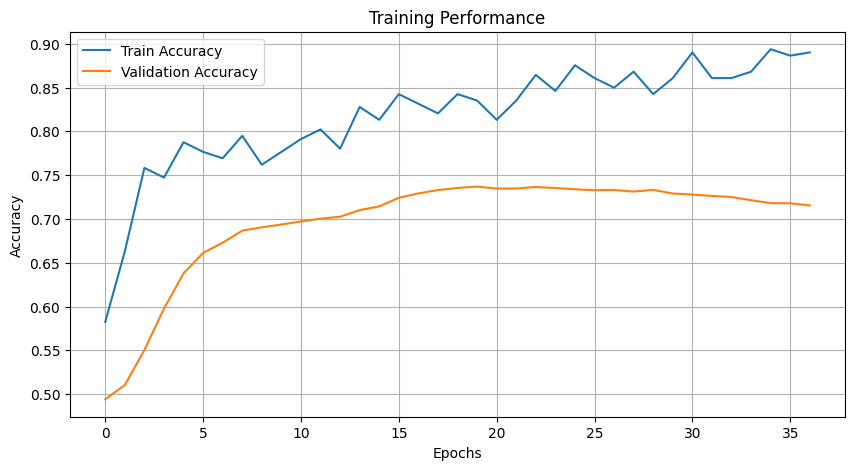

In [9]:
# ==============================
# 📈 5️⃣ Plot Training Performance
# ==============================

import matplotlib.pyplot as plt

def plot_training_history(history):
    """Plot accuracy and loss over training epochs."""
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training Performance")
    plt.grid(True)
    plt.show()

# Plot the results
plot_training_history(history)


2025-02-13 00:58:06.256169: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   


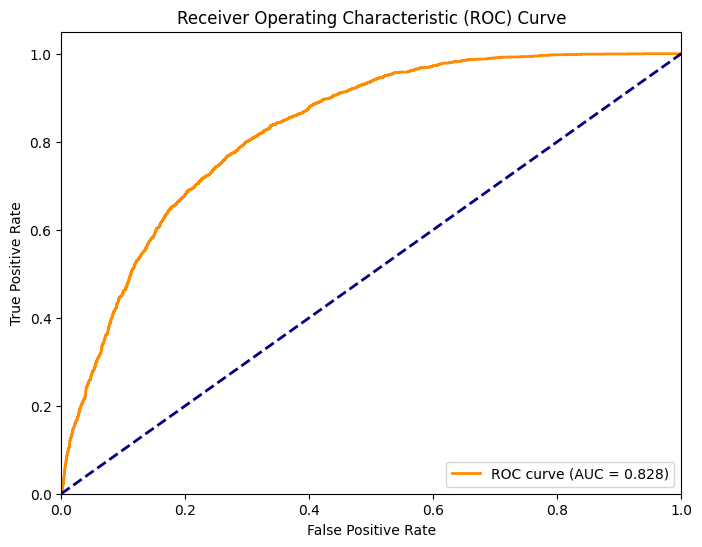

✅ Model AUC Score: 0.828


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, test_ds, input_dim):
    # Convert the dataset to a list so it can be reused.
    # This will unbatch the dataset, yielding tuples (features, labels).
    test_data = list(test_ds.unbatch().as_numpy_iterator())
    
    # Check if any data was extracted.
    if len(test_data) == 0:
        print("Test dataset is empty. Please check your data loading pipeline.")
        return
    
    # Unzip the data into features and labels
    test_features, test_labels = zip(*test_data)
    
    # Convert lists to NumPy arrays
    test_features = np.array(test_features).reshape(-1, input_dim)
    test_labels = np.array(test_labels).reshape(-1)
    
    # Make predictions on the test data
    y_pred = model.predict(test_features)
    
    # If your model has a single output, y_pred will be shape (n,1). Flatten if needed.
    if y_pred.ndim > 1 and y_pred.shape[1] == 1:
        y_pred = y_pred.flatten()
    
    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(test_labels, y_pred)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()
    
    print(f"✅ Model AUC Score: {roc_auc:.3f}")

# Call the function with the model and test dataset.
plot_roc_curve(best_model, test_ds, input_dim)


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# Verify GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Function to create model
def create_model(embeddings_size=1408, learning_rate=0.07, dropout=0.5, hidden_layer_sizes=[128, 32], weight_decay=0.0001, seed=None):
    inputs = tf.keras.Input(shape=(embeddings_size,))
    hidden = inputs
    for size in hidden_layer_sizes:
        hidden = tf.keras.layers.Dense(
            size,
            activation='relu',
            kernel_initializer=tf.keras.initializers.HeUniform(seed=seed),
            kernel_regularizer=tf.keras.regularizers.l2(l2=weight_decay),
            bias_regularizer=tf.keras.regularizers.l2(l2=weight_decay))(hidden)
        hidden = tf.keras.layers.BatchNormalization()(hidden)
        hidden = tf.keras.layers.Dropout(dropout, seed=seed)(hidden)
    output = tf.keras.layers.Dense(units=1, activation='sigmoid')(hidden)

    model = tf.keras.Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_focal_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()])
    return model


df = pd.read_csv(r"~/final_merged_data.csv")
X = np.array(df['embedding'].tolist())
y = df['label'].map({'1,0': 0, '0,1': 1}).values

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = create_model()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=32
)

# Evaluate the model
val_predictions = model.predict(X_val)

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_val, val_predictions)
auc = roc_auc_score(y_val, val_predictions)

# Plot ROC curve
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC: {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Print final metrics
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final validation AUC: {history.history['val_auc'][-1]:.4f}")


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1738891749.410415   24035 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


ValueError: Invalid dtype: str944320

In [7]:
# %% [markdown]
# # Local Training with Embeddings from a Single CSV File
#
# This notebook loads embedding data from a single CSV file, splits it into training and validation sets, and trains an MLP model on the embeddings to predict whether a sample is abnormal. The CSV file is assumed to have two columns:
#
# - **embedding**: a string representation of a list of floats (the embedding vector)
# - **label**: a string representation of a one-hot encoded list (e.g. `[1, 0]` for normal, `[0, 1]` for abnormal)
#
# Adjust the file path and parsing logic if your CSV format is different.

# %% [markdown]
# ## Imports and Environment Check

# %% [code]
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn.model_selection import train_test_split

import tensorflow as tf
# The LARS optimizer is imported from tensorflow_models.
# If not already installed, you might need to install it with: pip install tf-models-official
import tensorflow_models as tfm  

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# %% [markdown]
# ## Load and Parse the CSV Data
#
# The CSV file should contain the columns `embedding` and `label`.  
# - The **embedding** column contains a string (e.g., `"[0.1, 0.2, ...]"`) that we will convert to a list of floats.
# - The **label** column contains a string (e.g., `"[1, 0]"` or `"[0, 1]"`) that we will convert to a one-hot list and then to a binary value (0 for normal, 1 for abnormal).

# %% [code]
# Set the path to your CSV file (update this path as needed)
csv_path = r"~/final_merged_data.csv"  # Update with your CSV file path

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_path)
print("DataFrame head:")
display(df.head())

# Define a helper function to parse a string representation of a list
def parse_list_str(s):
    try:
        return ast.literal_eval(s)
    except Exception as e:
        print("Error parsing string:", s)
        raise e

# Parse the 'embedding' column and the 'label' column
df["embedding"] = df["embedding"].apply(parse_list_str)
df["label_parsed"] = df["label"].apply(parse_list_str)

# Convert the one-hot label to a binary value:
# Here we assume that if the second element is 1, the label is abnormal.
df["binary_label"] = df["label_parsed"].apply(lambda lst: 1 if lst[1] == 1 else 0)

print("Parsed DataFrame head:")
display(df.head())

# %% [markdown]
# ## Split the Data into Training and Validation Sets
#
# We use an 80/20 split for training and validation.

# %% [code]
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Training set size:", len(train_df))
print("Validation set size:", len(val_df))

# %% [markdown]
# ## Prepare TensorFlow Datasets
#
# Convert the embeddings and labels into NumPy arrays and then create TensorFlow datasets.

# %% [code]
# Convert embeddings and labels from the DataFrames into NumPy arrays
train_embeddings = np.array(train_df["embedding"].tolist())
train_labels = np.array(train_df["binary_label"].tolist())
val_embeddings = np.array(val_df["embedding"].tolist())
val_labels = np.array(val_df["binary_label"].tolist())

print("Train embeddings shape:", train_embeddings.shape)
print("Validation embeddings shape:", val_embeddings.shape)

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_embeddings, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_embeddings, val_labels))

# %% [markdown]
# ## Define the Model
#
# We define a multilayer perceptron (MLP) model that accepts an embedding vector as input and outputs a prediction. The model first reshapes the input (to support the original multi-token architecture), applies global average pooling, passes the data through hidden layers, and finally outputs a prediction using a sigmoid activation.
#
# The optimizer used is LARS (from `tensorflow_models`), and the loss function is `binary_focal_crossentropy`.

# %% [code]
def create_model(heads,
                 token_num=1,
                 embeddings_size=1408,
                 learning_rate=0.07,
                 dropout=0.5,
                 loss_weights=None,
                 hidden_layer_sizes=[128, 32],
                 weight_decay=0.0001,
                 seed=None) -> tf.keras.Model:
    """
    Creates an MLP model using a LARS optimizer.
    """
    inputs = tf.keras.Input(shape=(token_num * embeddings_size,))
    inputs_reshape = tf.keras.layers.Reshape((token_num, embeddings_size))(inputs)
    inputs_pooled = tf.keras.layers.GlobalAveragePooling1D(data_format='channels_last')(inputs_reshape)
    hidden = inputs_pooled

    for size in hidden_layer_sizes:
        hidden = tf.keras.layers.Dense(
            size,
            activation='relu',
            kernel_initializer=tf.keras.initializers.HeUniform(seed=seed),
            kernel_regularizer=tf.keras.regularizers.l2(l2=weight_decay),
            bias_regularizer=tf.keras.regularizers.l2(l2=weight_decay)
        )(hidden)
        hidden = tf.keras.layers.BatchNormalization()(hidden)
        hidden = tf.keras.layers.Dropout(dropout, seed=seed)(hidden)

    output = tf.keras.layers.Dense(
        units=len(heads),
        activation='sigmoid',
        kernel_initializer=tf.keras.initializers.HeUniform(seed=seed)
    )(hidden)

    outputs = {}
    for i, head in enumerate(heads):
        outputs[head] = tf.keras.layers.Lambda(lambda x, i=i: x[..., i:i+1], name=head.lower())(output)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tfm.optimization.lars.LARS(learning_rate=learning_rate),
        loss={head: 'binary_focal_crossentropy' for head in heads},
        loss_weights=loss_weights or 1.0,
        weighted_metrics=[
            tf.keras.metrics.FalsePositives(),
            tf.keras.metrics.FalseNegatives(),
            tf.keras.metrics.TruePositives(),
            tf.keras.metrics.TrueNegatives(),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(curve='PR', name='auc_pr')
        ]
    )
    return model

# %% [markdown]
# ## Build the Model
#
# We determine the embedding size from the training data and create the model.  
# The model has a single output head (named `"abnormal"`) which predicts the probability of an abnormal condition.

# %% [code]
# Determine the embedding size (number of dimensions) from the training embeddings
embedding_size = train_embeddings.shape[1]
print("Detected embedding size:", embedding_size)

DIAGNOSIS = "abnormal"  # Name for the prediction head

model = create_model(
    heads=[DIAGNOSIS],
    embeddings_size=embedding_size,
    learning_rate=0.1,   # Adjust learning rate as needed
    dropout=0.5,
    hidden_layer_sizes=[128, 32],
    weight_decay=0.0001,
    seed=42
)

model.summary()

# %% [markdown]
# ## Train the Model
#
# The model is trained over 35 epochs using a batch size of 512 for training and 32 for validation.

# %% [code]
history = model.fit(
    x=train_ds.batch(512).prefetch(tf.data.AUTOTUNE).cache(),
    validation_data=val_ds.batch(32).cache(),
    epochs=35,
)

# %% [markdown]
# ## Evaluate the Model and Plot the ROC Curve
#
# We generate predictions for the validation dataset, compute the ROC curve and AUC score, and then plot the ROC curve.

# %% [code]
# Collect predictions and true labels from the validation dataset
rows = []
for embeddings, label in val_ds.batch(1):
    pred = model(embeddings)[DIAGNOSIS].numpy().flatten()[0]
    true_val = label.numpy().flatten()[0]
    rows.append({
        f'{DIAGNOSIS}_prediction': pred,
        f'{DIAGNOSIS}_value': true_val
    })

eval_df = pd.DataFrame(rows)
print("Evaluation DataFrame head:")
display(eval_df.head())

# Compute ROC curve and AUC score
labels = eval_df[f'{DIAGNOSIS}_value'].values
predictions = eval_df[f'{DIAGNOSIS}_prediction'].values

false_positive_rate, true_positive_rate, thresholds = sklearn.metrics.roc_curve(
    labels,
    predictions,
    drop_intermediate=False
)
auc = sklearn.metrics.roc_auc_score(labels, predictions)
print("Validation AUC:", auc)

# %% [code]
def plot_curve(x, y, auc, x_label=None, y_label=None, label=None):
    plt.figure(figsize=(10, 10))
    plt.plot(x, y, label=f'{label} (AUC: {auc:.3f})', color='black')
    plt.legend(loc='lower right', fontsize=18)
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    if x_label:
        plt.xlabel(x_label, fontsize=24)
    if y_label:
        plt.ylabel(y_label, fontsize=24)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True)
    plt.show()

plot_curve(false_positive_rate, true_positive_rate, auc,
           x_label='False Positive Rate',
           y_label='True Positive Rate',
           label=DIAGNOSIS)


ImportError: cannot import name 'float8_e4m3b11fnuz' from 'tensorflow.python.framework.dtypes' (/home/bahram/.local/lib/python3.10/site-packages/tensorflow/python/framework/dtypes.py)